# V3.1 Feature Engineering — V3 (V2.5 + Grid) + Nuclear Power

Extends `V3_15min_features.csv` (V2.5 features + cross-border grid) with
**Finland nuclear power generation** (measured, MW) from Fingrid.

**New features added (6):**
- `nuclear_power_mw` — current-period nuclear generation (MW)
- `nuclear_lag_96` — nuclear 24h ago (96 × 15-min)
- `nuclear_lag_672` — nuclear 7d ago (672 × 15-min)
- `nuclear_rolling_mean_24h` — mean of past 24h
- `nuclear_rolling_mean_7d` — mean of past 7d
- `nuclear_change_1d` — change vs 24h ago

> This is the **SHARED dataset**: partner's LightGBM calls it "V3",
> the XGBoost V4 model trains on it too.
>
> Nuclear generation is **measured** (realized) — at live forecast time the
> current-period value is unknown, so the live-feasible features are the lags.

Output: `V3.1_15min_features.csv`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

## 1. Load V3 (V2.5 + Grid) and Nuclear

In [2]:
df = pd.read_csv('V3_15min_features.csv')
df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_convert('Europe/Helsinki')
df = df.sort_values('datetime').reset_index(drop=True)

nuc = pd.read_csv('../originalData/Nuclear/nuclear_measured_15min.csv')
nuc['datetime'] = pd.to_datetime(nuc['datetime'], utc=True).dt.tz_convert('Europe/Helsinki')
nuc = nuc.sort_values('datetime').reset_index(drop=True)

print('V3 shape:', df.shape)
print('Nuclear shape:', nuc.shape)
print('Nuclear range:', nuc['datetime'].min(), '->', nuc['datetime'].max())

V3 shape: (105216, 64)
Nuclear shape: (105216, 2)
Nuclear range: 2023-01-01 02:00:00+02:00 -> 2026-01-01 01:45:00+02:00


## 2. Merge on Datetime (left-join)

Fill small gaps (start-of-series + 250 NaN slots) with ffill/bfill — nuclear is
stable base load, so filling is safe.

In [3]:
df = df.merge(nuc[['datetime', 'nuclear_power_mw']], on='datetime', how='left')

print('NaN nuclear after merge:', df['nuclear_power_mw'].isna().sum())
df['nuclear_power_mw'] = df['nuclear_power_mw'].ffill().bfill()
print('NaN nuclear after fill  :', df['nuclear_power_mw'].isna().sum())

NaN nuclear after merge: 258
NaN nuclear after fill  : 0


## 3. Nuclear Features (lags + rolling)

Same style as the grid lags: 24h (lag_96) and 7d (lag_672) are computable at
inference from measured history; rolling stats capture base-load level.

In [4]:
df['nuclear_lag_96']  = df['nuclear_power_mw'].shift(96)     # 24h ago
df['nuclear_lag_672'] = df['nuclear_power_mw'].shift(672)    # 7d ago
df['nuclear_rolling_mean_24h'] = df['nuclear_power_mw'].rolling(96).mean()
df['nuclear_rolling_mean_7d']  = df['nuclear_power_mw'].rolling(672).mean()
df['nuclear_change_1d'] = df['nuclear_power_mw'] - df['nuclear_power_mw'].shift(96)

nuclear_cols = ['nuclear_power_mw', 'nuclear_lag_96', 'nuclear_lag_672',
                'nuclear_rolling_mean_24h', 'nuclear_rolling_mean_7d',
                'nuclear_change_1d']
print('Nuclear feature columns:', nuclear_cols)
print('\nNaN counts:')
print(df[nuclear_cols].isna().sum())

Nuclear feature columns: ['nuclear_power_mw', 'nuclear_lag_96', 'nuclear_lag_672', 'nuclear_rolling_mean_24h', 'nuclear_rolling_mean_7d', 'nuclear_change_1d']

NaN counts:
nuclear_power_mw              0
nuclear_lag_96               96
nuclear_lag_672             672
nuclear_rolling_mean_24h     95
nuclear_rolling_mean_7d     671
nuclear_change_1d            96
dtype: int64


## 4. Sanity Check

Total columns: 70
Total rows:    105216

New V3.1 columns vs V3 (6):
['nuclear_power_mw', 'nuclear_lag_96', 'nuclear_lag_672', 'nuclear_rolling_mean_24h', 'nuclear_rolling_mean_7d', 'nuclear_change_1d']

Nuclear stats:
       nuclear_power_mw  nuclear_lag_96  nuclear_lag_672  \
count          105216.0        105120.0         104544.0   
mean             3612.0          3611.5           3610.1   
std               676.5           676.6            678.1   
min              1521.7          1521.7           1521.7   
25%              2920.6          2920.4           2919.3   
50%              3810.3          3808.1           3805.7   
75%              4203.6          4203.7           4204.4   
max              4408.7          4408.7           4408.7   

       nuclear_rolling_mean_24h  nuclear_rolling_mean_7d  nuclear_change_1d  
count                  105121.0                 104545.0           105120.0  
mean                     3611.4                   3609.5               -0.2  
std   

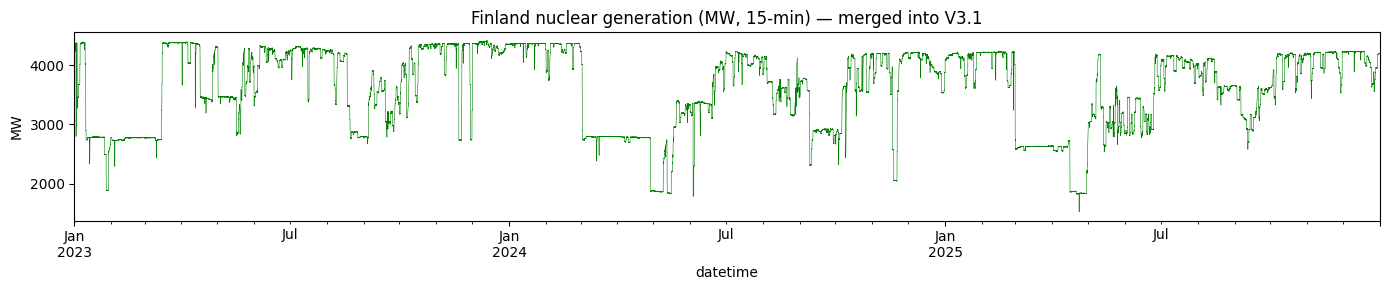

In [5]:
print(f'Total columns: {len(df.columns)}')
print(f'Total rows:    {len(df)}')

v3_cols = set(pd.read_csv('V3_15min_features.csv', nrows=0).columns)
new_cols = [c for c in df.columns if c not in v3_cols]
print(f'\nNew V3.1 columns vs V3 ({len(new_cols)}):')
print(new_cols)

print('\nNuclear stats:')
print(df[nuclear_cols].describe().round(1))

# quick plot of nuclear generation
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 3))
df.set_index('datetime')['nuclear_power_mw'].plot(linewidth=0.4, color='green')
plt.title('Finland nuclear generation (MW, 15-min) — merged into V3.1')
plt.ylabel('MW')
plt.tight_layout()
plt.show()

## 5. Save

In [6]:
out_path = 'V3.1_15min_features.csv'
df.to_csv(out_path, index=False)

print(f'Saved → {out_path}')
print(f'Rows  : {len(df)}')
print(f'Cols  : {len(df.columns)}  (was 64 in V3, +{len(df.columns)-64} new nuclear features)')
print(f'Range : {df["datetime"].min()} → {df["datetime"].max()}')

Saved → V3.1_15min_features.csv
Rows  : 105216
Cols  : 70  (was 64 in V3, +6 new nuclear features)
Range : 2023-01-01 00:00:00+02:00 → 2025-12-31 23:45:00+02:00
